# NeuroRAG — Exploratory Data Analysis (EDA)
### Run AFTER neurorag_READY.ipynb cells 1-13 so SQLite DB is populated

In [1]:
import sqlite3, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

DB_PATH = r"C:\Users\KARTHIKEYA\Desktop\neurorag.db"
conn   = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

# Load everything into a DataFrame
df = pd.read_sql_query("SELECT * FROM eeg_narratives", conn)

# Remove duplicates if main loop was run multiple times
df = df.drop_duplicates(subset=["subject_id", "condition", "file_name"])
df = df.reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Conditions:", df["condition"].unique())
print()
print(df.groupby("condition").size())


Dataset shape: (112, 11)
Conditions: <StringArray>
['CMPS', 'HORROR', 'MUSIC', 'SCWT', 'TMCT']
Length: 5, dtype: str

condition
CMPS      22
HORROR    22
MUSIC     20
SCWT      24
TMCT      24
dtype: int64


## EDA 1 — Stress Label Distribution per Condition

C:\Users\KARTHIKEYA\AppData\Local\Temp\ipykernel_5372\3572976246.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=30, ha="right", fontsize=8)
C:\Users\KARTHIKEYA\AppData\Local\Temp\ipykernel_5372\3572976246.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=30, ha="right", fontsize=8)
C:\Users\KARTHIKEYA\AppData\Local\Temp\ipykernel_5372\3572976246.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=30, ha="right", fontsize=8)
C:\Users\KARTHIKEYA\AppData\Local\Temp\ipykernel_5372\3572976246.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using 

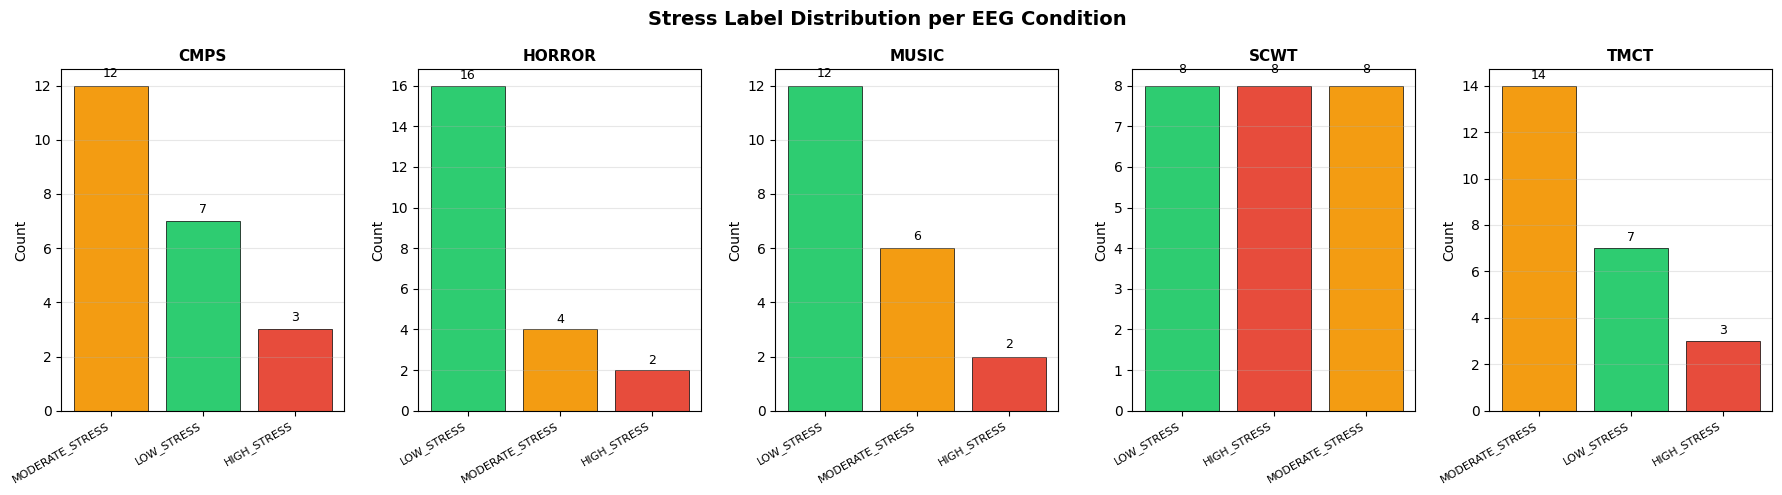

Saved: eda_stress_distribution.png


In [2]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
colors = {"HIGH_STRESS": "#e74c3c", "MODERATE_STRESS": "#f39c12", "LOW_STRESS": "#2ecc71"}

for ax, (cond, group) in zip(axes, df.groupby("condition")):
    counts = group["stress_label"].value_counts()
    bar_colors = [colors.get(l, "gray") for l in counts.index]
    ax.bar(counts.index, counts.values, color=bar_colors, edgecolor="black", linewidth=0.5)
    ax.set_title(cond, fontsize=11, fontweight="bold")
    ax.set_ylabel("Count")
    ax.set_xticklabels(counts.index, rotation=30, ha="right", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.3, str(v), ha="center", fontsize=9)

fig.suptitle("Stress Label Distribution per EEG Condition", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\KARTHIKEYA\Desktop\eda_stress_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_stress_distribution.png")


## EDA 2 — Biomarker Comparison Across Conditions

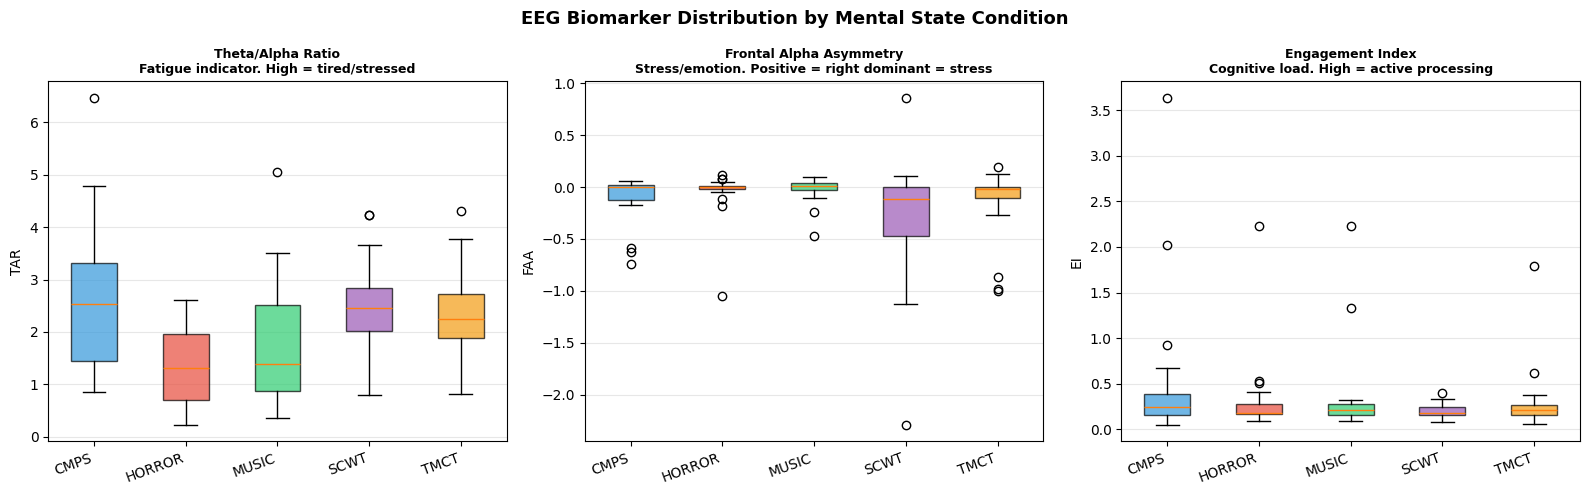

Saved: eda_biomarkers.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

biomarkers = [
    ("tar",  "Theta/Alpha Ratio",       "Fatigue indicator. High = tired/stressed"),
    ("faa",  "Frontal Alpha Asymmetry", "Stress/emotion. Positive = right dominant = stress"),
    ("ei",   "Engagement Index",        "Cognitive load. High = active processing")
]

cond_order  = ["CMPS", "HORROR", "MUSIC", "SCWT", "TMCT"]
cond_colors = ["#3498db", "#e74c3c", "#2ecc71", "#9b59b6", "#f39c12"]

for ax, (col, title, subtitle) in zip(axes, biomarkers):
    data_by_cond = [df[df["condition"] == c][col].values for c in cond_order]
    bp = ax.boxplot(data_by_cond, patch_artist=True, notch=False)
    for patch, color in zip(bp["boxes"], cond_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(cond_order, rotation=20, ha="right")
    ax.set_title(f"{title}\n{subtitle}", fontsize=9, fontweight="bold")
    ax.set_ylabel(col.upper())
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("EEG Biomarker Distribution by Mental State Condition", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\KARTHIKEYA\Desktop\eda_biomarkers.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_biomarkers.png")


## EDA 3 — Stress Score Heatmap (Subject × Condition)

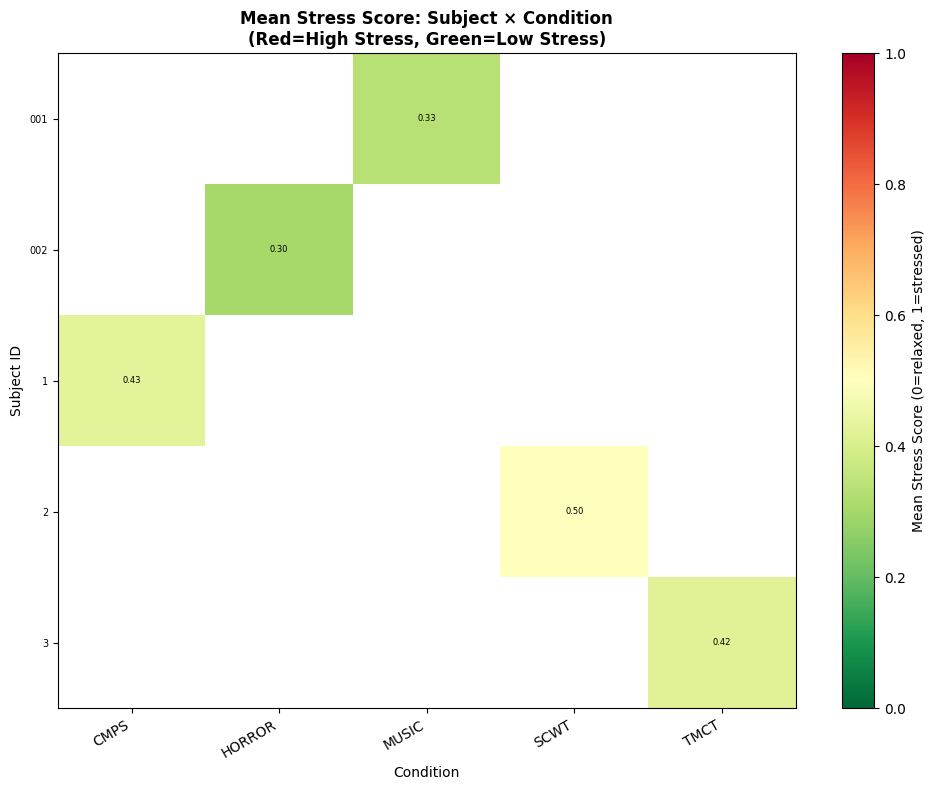

Saved: eda_heatmap.png


In [4]:
# Pivot: rows = subjects, columns = conditions, values = mean stress score
pivot = df.pivot_table(
    index="subject_id",
    columns="condition",
    values="stress_score",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(pivot.values, cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="Mean Stress Score (0=relaxed, 1=stressed)")

ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
ax.set_yticklabels(pivot.index, fontsize=7)
ax.set_xlabel("Condition")
ax.set_ylabel("Subject ID")
ax.set_title("Mean Stress Score: Subject × Condition\n(Red=High Stress, Green=Low Stress)", fontweight="bold")

# Add value annotations
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6)

plt.tight_layout()
plt.savefig(r"C:\Users\KARTHIKEYA\Desktop\eda_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_heatmap.png")


## EDA 4 — Mean Band Powers per Condition

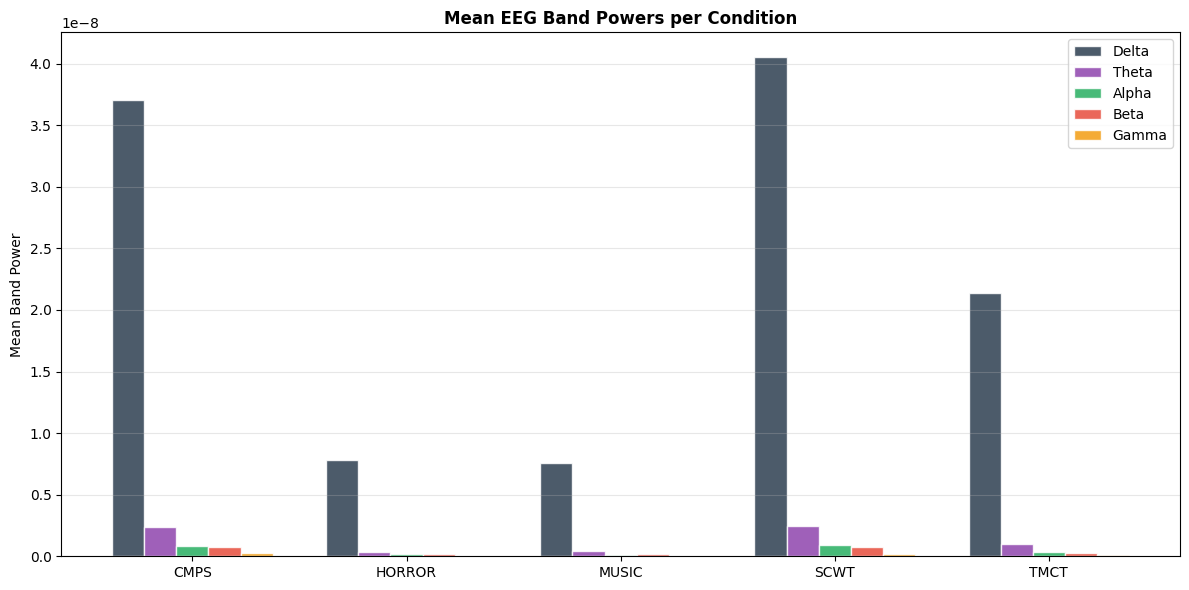

Saved: eda_band_powers.png


In [5]:
# Parse embeddings to get band powers
# dims 0-4 of embedding = mean delta, theta, alpha, beta, gamma
band_names = ["Delta", "Theta", "Alpha", "Beta", "Gamma"]

band_data = {band: {cond: [] for cond in cond_order} for band in band_names}

for _, row in df.iterrows():
    emb = json.loads(row["embedding"])
    for i, band in enumerate(band_names):
        band_data[band][row["condition"]].append(emb[i])

# Compute means
means = pd.DataFrame({
    band: [np.mean(band_data[band][c]) for c in cond_order]
    for band in band_names
}, index=cond_order)

fig, ax = plt.subplots(figsize=(12, 6))
x    = np.arange(len(cond_order))
w    = 0.15
band_colors = ["#2c3e50", "#8e44ad", "#27ae60", "#e74c3c", "#f39c12"]

for i, (band, color) in enumerate(zip(band_names, band_colors)):
    ax.bar(x + i*w, means[band], w, label=band, color=color, alpha=0.85, edgecolor="white")

ax.set_xticks(x + w*2)
ax.set_xticklabels(cond_order)
ax.set_ylabel("Mean Band Power")
ax.set_title("Mean EEG Band Powers per Condition", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(r"C:\Users\KARTHIKEYA\Desktop\eda_band_powers.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_band_powers.png")


## EDA 5 — Retrieval Confusion Matrix

Running retrieval on all files...


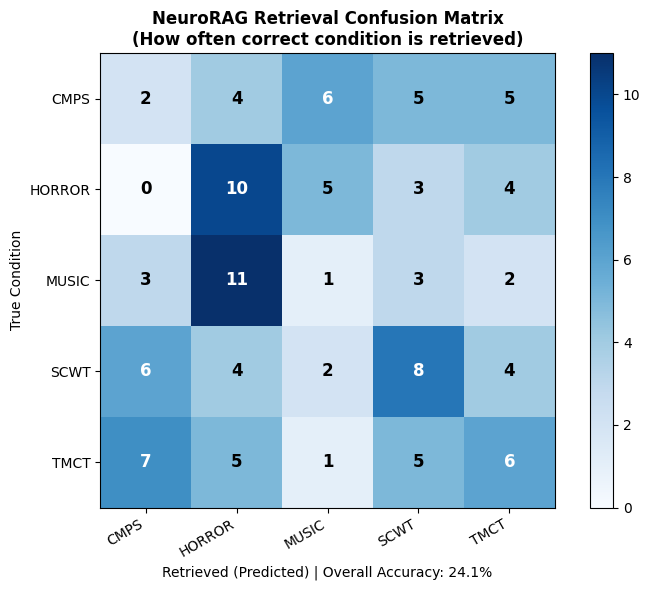

Overall Retrieval Accuracy: 24.1%


In [6]:
from scipy.signal import welch as scipy_welch
from collections import Counter

# For each file, retrieve top-5 and record what condition was voted
print("Running retrieval on all files...")

def cosine_similarity(a, b):
    a, b = np.array(a), np.array(b)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10))

def retrieve_from_db(query_emb, top_k=5):
    cursor.execute("SELECT subject_id, condition, stress_label, embedding FROM eeg_narratives")
    rows = cursor.fetchall()
    scored = []
    for sid, cond, stress, emb_json in rows:
        emb = json.loads(emb_json)
        sim = cosine_similarity(query_emb, emb)
        scored.append((sim, cond))
    scored.sort(reverse=True)
    return [c for _, c in scored[1:top_k+1]]  # skip rank 1 (self)

true_labels = []
pred_labels = []

for _, row in df.iterrows():
    emb = json.loads(row["embedding"])
    retrieved = retrieve_from_db(emb, top_k=5)
    pred = Counter(retrieved).most_common(1)[0][0]
    true_labels.append(row["condition"])
    pred_labels.append(pred)

# Build confusion matrix manually
labels = cond_order
matrix = pd.DataFrame(0, index=labels, columns=labels)
for t, p in zip(true_labels, pred_labels):
    matrix.loc[t, p] += 1

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(matrix.values, cmap="Blues")
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_yticklabels(labels)
ax.set_xlabel("Retrieved (Predicted)")
ax.set_ylabel("True Condition")
ax.set_title("NeuroRAG Retrieval Confusion Matrix\n(How often correct condition is retrieved)", fontweight="bold")

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, str(matrix.values[i, j]), ha="center", va="center",
                color="white" if matrix.values[i, j] > matrix.values.max()/2 else "black",
                fontsize=12, fontweight="bold")

accuracy = sum(t == p for t, p in zip(true_labels, pred_labels)) / len(true_labels)
ax.set_xlabel(f"Retrieved (Predicted) | Overall Accuracy: {accuracy*100:.1f}%")

plt.tight_layout()
plt.savefig(r"C:\Users\KARTHIKEYA\Desktop\eda_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Overall Retrieval Accuracy: {accuracy*100:.1f}%")


## EDA 6 — Summary Statistics Table

In [7]:
summary = df.groupby("condition").agg(
    n_files       = ("file_name", "count"),
    mean_stress   = ("stress_score", "mean"),
    std_stress    = ("stress_score", "std"),
    mean_tar      = ("tar", "mean"),
    mean_faa      = ("faa", "mean"),
    mean_ei       = ("ei", "mean"),
    pct_high      = ("stress_label", lambda x: (x == "HIGH_STRESS").mean() * 100)
).round(3)

print("=" * 70)
print("NEURORAG DATASET SUMMARY")
print("=" * 70)
print(summary.to_string())
print()
print("TAR  = Theta/Alpha Ratio (high = fatigued)")
print("FAA  = Frontal Alpha Asymmetry (positive = stress/withdrawal)")
print("EI   = Engagement Index (high = active cognitive load)")
print("% High = percentage of recordings classified as HIGH_STRESS")

summary.to_csv(r"C:\Users\KARTHIKEYA\Desktop\neurorag_summary.csv")
print("\nSaved: neurorag_summary.csv")


NEURORAG DATASET SUMMARY
           n_files  mean_stress  std_stress  mean_tar  mean_faa  mean_ei  pct_high
condition                                                                         
CMPS            22        0.428       0.153     2.603    -0.108    0.519    13.636
HORROR          22        0.302       0.162     1.411    -0.048    0.320     9.091
MUSIC           20        0.332       0.148     1.800    -0.027    0.366    10.000
SCWT            24        0.502       0.187     2.505    -0.296    0.207    33.333
TMCT            24        0.418       0.154     2.314    -0.147    0.285    12.500

TAR  = Theta/Alpha Ratio (high = fatigued)
FAA  = Frontal Alpha Asymmetry (positive = stress/withdrawal)
EI   = Engagement Index (high = active cognitive load)
% High = percentage of recordings classified as HIGH_STRESS

Saved: neurorag_summary.csv
